# Investigation: Why Does the Stationary Model Have High HPD Overlap?

## Question

In `fig4.ipynb`, the Continuous model is run with `movement_var=0.1` (near-stationary: the
predictive posterior barely moves from the filtered posterior). The mean HPD overlap for this
model is **0.88**. The question is: **what cells are driving this high value?**

Hypotheses:
1. **Interneurons / non-place cells**: cells with flat firing rates across the track produce
   uniform likelihoods that trivially overlap with any HPD region.
2. **Broad place field cells**: cells with wide spatial tuning produce spread-out likelihoods
   that overlap with any concentrated predictive posterior.
3. **Well-fit place cells**: the model genuinely captures position well for most spikes.

## Mechanistic Logic

HPD overlap measures: what fraction of the **likelihood's** mass falls inside the **predictive
posterior's** 95% HPD region?

- **Concentrated predictive posterior** (movement_var=0.1): HPD region covers a small part of the track.
- **Narrow place field + spike at correct location**: likelihood is concentrated and overlaps → **high HPD overlap** (genuinely good fit).
- **Narrow place field + spike at wrong location**: likelihood is concentrated elsewhere → **low HPD overlap** (detects misfit).
- **Broad/flat place field + spike anywhere**: likelihood is spread across the track → always overlaps with the HPD region → **high HPD overlap** (uninformative, inflates the average).

So **broad-field cells cannot produce low HPD overlap regardless of model quality**. If many cells
have broad fields, the population mean HPD overlap is pulled up.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

from statespacecheck_paper.load_local_data import load_neural_recording_from_files
from statespacecheck_paper.real_data_analysis import (
    compute_model_diagnostics,
    extract_place_fields,
    get_spike_counts,
)
from statespacecheck_paper.style import set_figure_defaults

set_figure_defaults()

## 1. Load Data and Cached Model

We load the pre-fitted Continuous model and results from `data/intermediates/`.
The model was fit with `position_std=sqrt(12.5)` and the default `movement_var=6.0`.

**Key**: We then override `movement_var=0.1` and re-decode to create the "stationary"
version, matching what was done in `fig4.ipynb`.

In [2]:
DATA_PATH = Path("../data")
ANIMAL_DATE_EPOCH = "j1620210710_02_r1"

# Load raw data
data = load_neural_recording_from_files(DATA_PATH, ANIMAL_DATE_EPOCH)
position_info = data["position_info"]
time = position_info.index.values
position = position_info[["head_position_x", "head_position_y"]].values
linear_position = position_info["linear_position"].values
spike_times_list = list(data["spike_times"])
n_cells = len(spike_times_list)

print(f"Loaded {n_cells} cells, {len(time)} time points")
print(f"Linear position range: {linear_position.min():.1f} - {linear_position.max():.1f}")

Loaded 203 cells, 709321 time points
Linear position range: 0.3 - 608.5


In [3]:
# Load cached model
model = joblib.load(DATA_PATH / "intermediates" / "cont_model.pkl")

print(f"Original movement_var: {model.continuous_transition_types[0][0].movement_var}")

# Extract place fields (these are independent of movement_var)
place_fields, position_bins = extract_place_fields(model)
print(f"Place fields: {place_fields.shape} (n_cells, n_bins)")
print(f"Position bins: {position_bins.shape}")

# Get spike counts
spike_counts = get_spike_counts(spike_times_list, time)
print(f"Spike counts: {spike_counts.shape} (n_time, n_cells)")
print(f"Total spikes: {spike_counts.sum():,}")

/Users/edeno/Documents/GitHub/statespacecheck-paper/.venv/lib/python3.11/site-packages/non_local_detector/likelihoods/clusterless_gmm.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # type: ignore[import-untyped]


Original movement_var: 6.0
Place fields: (203, 256) (n_cells, n_bins)
Position bins: (256,)
Spike counts: (709321, 203) (n_time, n_cells)
Total spikes: 870,018


## 2. Characterize Place Fields

Before looking at diagnostics, let's understand what kinds of cells we have.
We measure:
- **Peak firing rate**: maximum rate across all position bins
- **Mean firing rate**: average rate across all bins (proportional to overall firing rate)
- **Spatial selectivity**: peak_rate / mean_rate (how peaked the tuning is)
- **Field width**: fraction of track where rate > 25% of peak (spatial extent)

In [4]:
# Filter to track interior bins (same as used in diagnostics)
pf = place_fields[:, model.is_track_interior_state_bins_]
pos = position_bins[model.is_track_interior_state_bins_]
n_bins_interior = pf.shape[1]

print(f"Interior bins: {n_bins_interior} / {place_fields.shape[1]}")

# Compute place field properties for each cell
peak_rate = np.nanmax(pf, axis=1)  # (n_cells,)
mean_rate = np.nanmean(pf, axis=1)  # (n_cells,)
total_rate = np.nansum(pf, axis=1)  # sum of rates across bins

# Spatial selectivity: how peaked is the tuning?
# High = narrow place field, Low = broad/flat field
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", "invalid value")
    selectivity = peak_rate / mean_rate  # ratio of peak to mean
selectivity[mean_rate == 0] = np.nan

# Field width: fraction of track with rate > 25% of peak
field_width_frac = np.array(
    [
        np.nansum(pf[i] > 0.25 * peak_rate[i]) / n_bins_interior if peak_rate[i] > 0 else 1.0
        for i in range(n_cells)
    ]
)

# Total spike count per cell
total_spikes_per_cell = spike_counts.sum(axis=0)  # (n_cells,)

# Peak position (where the cell fires most)
peak_position = pos[np.nanargmax(pf, axis=1)]

print("\n=== Place Field Summary ===")
print(
    f"Peak rate: min={peak_rate.min():.5f}, median={np.median(peak_rate):.5f}, max={peak_rate.max():.4f}"
)
print(
    f"Mean rate: min={mean_rate.min():.6f}, median={np.median(mean_rate):.5f}, max={mean_rate.max():.4f}"
)
print(
    f"Selectivity: min={np.nanmin(selectivity):.2f}, median={np.nanmedian(selectivity):.2f}, max={np.nanmax(selectivity):.2f}"
)
print(
    f"Field width: min={field_width_frac.min():.3f}, median={np.median(field_width_frac):.3f}, max={field_width_frac.max():.3f}"
)
print(
    f"Total spikes: min={total_spikes_per_cell.min()}, median={np.median(total_spikes_per_cell):.0f}, max={total_spikes_per_cell.max()}"
)

Interior bins: 248 / 256

=== Place Field Summary ===
Peak rate: min=0.00000, median=0.00402, max=0.1636
Mean rate: min=0.000000, median=0.00036, max=0.1111
Selectivity: min=1.00, median=9.72, max=45.49
Field width: min=0.028, median=0.137, max=1.000
Total spikes: min=0, median=108, max=63589


In [5]:
# Categorize cells by field width
# Narrow: <15% of track, Medium: 15-50%, Broad: >50%
is_narrow = field_width_frac < 0.15
is_medium = (field_width_frac >= 0.15) & (field_width_frac < 0.50)
is_broad = field_width_frac >= 0.50

# Also flag potential interneurons: very high firing rate, low selectivity
# Interneurons typically have high mean rates and fire everywhere
is_high_rate = mean_rate > np.percentile(mean_rate[mean_rate > 0], 90)
is_low_selectivity = selectivity < np.nanpercentile(selectivity, 25)
is_potential_interneuron = is_high_rate & is_low_selectivity

print("=== Cell Categories ===")
print(f"Narrow field (<15% of track): {is_narrow.sum()} cells")
print(f"Medium field (15-50%):        {is_medium.sum()} cells")
print(f"Broad field (>50%):           {is_broad.sum()} cells")
print("")
print(
    f"Potential interneurons (high rate + low selectivity): {is_potential_interneuron.sum()} cells"
)
print(f"  (high rate threshold: mean_rate > {np.percentile(mean_rate[mean_rate > 0], 90):.5f})")
print(f"  (low selectivity threshold: selectivity < {np.nanpercentile(selectivity, 25):.2f})")

=== Cell Categories ===
Narrow field (<15% of track): 107 cells
Medium field (15-50%):        44 cells
Broad field (>50%):           52 cells

Potential interneurons (high rate + low selectivity): 21 cells
  (high rate threshold: mean_rate > 0.01744)
  (low selectivity threshold: selectivity < 3.06)


## 3. Visualize Place Fields by Category

Let's look at what the place fields actually look like for each category.
This makes the distinction between narrow, medium, and broad fields concrete.

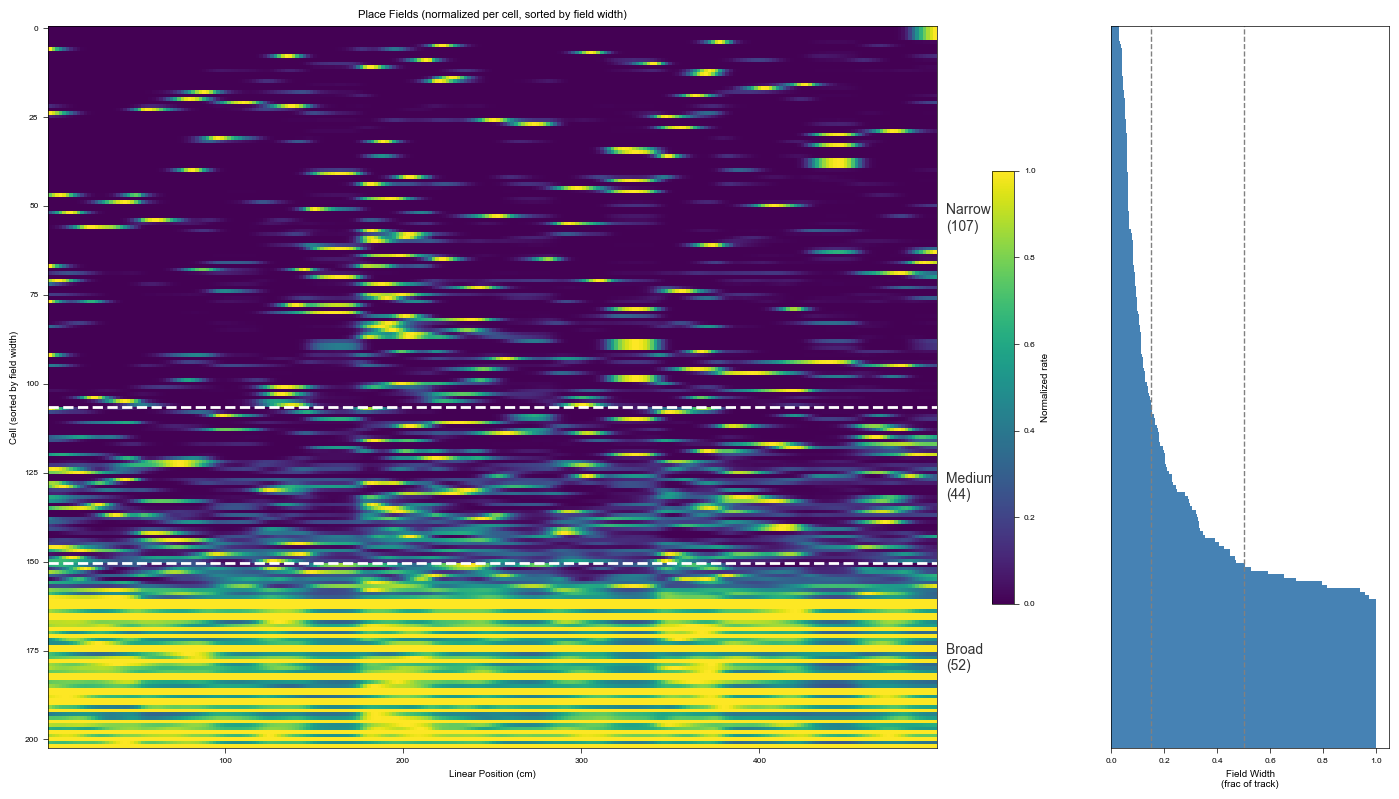

In [6]:
# Plot ALL place fields as a heatmap, sorted by field width
sort_order = np.argsort(field_width_frac)
pf_sorted = pf[sort_order]

# Normalize each cell's place field to [0, 1] for visualization
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", "invalid value")
    pf_normalized = pf_sorted / np.nanmax(pf_sorted, axis=1, keepdims=True)
pf_normalized = np.nan_to_num(pf_normalized, nan=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [4, 1]})

# Heatmap of normalized place fields
ax = axes[0]
im = ax.imshow(
    pf_normalized,
    aspect="auto",
    cmap="viridis",
    extent=[pos.min(), pos.max(), n_cells - 0.5, -0.5],
    interpolation="nearest",
)
ax.set_xlabel("Linear Position (cm)")
ax.set_ylabel("Cell (sorted by field width)")
ax.set_title("Place Fields (normalized per cell, sorted by field width)")
plt.colorbar(im, ax=ax, label="Normalized rate", shrink=0.6)

# Add category boundaries
narrow_count = is_narrow[sort_order].sum()
medium_count = is_medium[sort_order].sum()
# Find the boundaries in sorted order
widths_sorted = field_width_frac[sort_order]
narrow_boundary = np.searchsorted(widths_sorted, 0.15)
broad_boundary = np.searchsorted(widths_sorted, 0.50)
ax.axhline(narrow_boundary - 0.5, color="white", linewidth=2, linestyle="--")
ax.axhline(broad_boundary - 0.5, color="white", linewidth=2, linestyle="--")
ax.text(
    pos.max() + 5,
    narrow_boundary / 2,
    f"Narrow\n({is_narrow.sum()})",
    va="center",
    fontsize=10,
    color="#333",
)
ax.text(
    pos.max() + 5,
    (narrow_boundary + broad_boundary) / 2,
    f"Medium\n({is_medium.sum()})",
    va="center",
    fontsize=10,
    color="#333",
)
ax.text(
    pos.max() + 5,
    (broad_boundary + n_cells) / 2,
    f"Broad\n({is_broad.sum()})",
    va="center",
    fontsize=10,
    color="#333",
)

# Side panel: field width bar chart
ax2 = axes[1]
ax2.barh(np.arange(n_cells), widths_sorted, color="steelblue", height=1.0, edgecolor="none")
ax2.axvline(0.15, color="gray", linewidth=1, linestyle="--")
ax2.axvline(0.50, color="gray", linewidth=1, linestyle="--")
ax2.set_xlabel("Field Width\n(frac of track)")
ax2.set_ylim(n_cells - 0.5, -0.5)
ax2.set_yticks([])

fig.tight_layout()
plt.show()

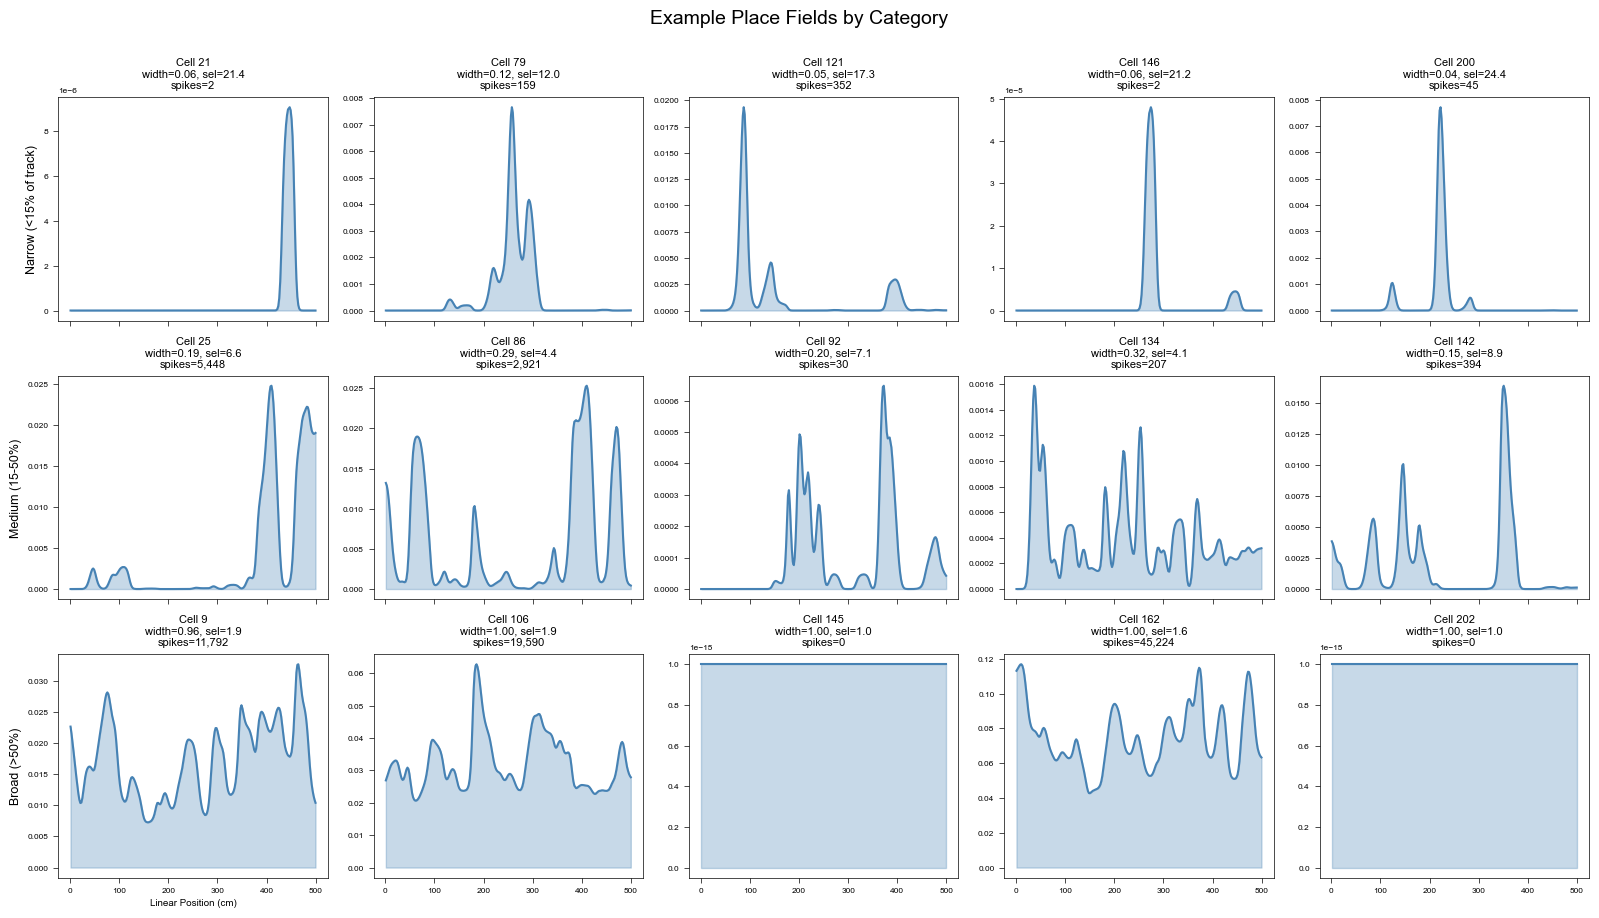

In [7]:
# Show example place fields from each category
fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharex=True)

categories = [
    ("Narrow (<15% of track)", is_narrow),
    ("Medium (15-50%)", is_medium),
    ("Broad (>50%)", is_broad),
]

for row, (cat_name, cat_mask) in enumerate(categories):
    cat_indices = np.where(cat_mask)[0]
    # Pick 5 random examples (or fewer if category is small)
    rng = np.random.default_rng(42)
    n_examples = min(5, len(cat_indices))
    example_indices = rng.choice(cat_indices, size=n_examples, replace=False)
    example_indices = np.sort(example_indices)

    for col in range(5):
        ax = axes[row, col]
        if col < n_examples:
            cell_idx = example_indices[col]
            ax.fill_between(pos, pf[cell_idx], alpha=0.3, color="steelblue")
            ax.plot(pos, pf[cell_idx], color="steelblue", linewidth=1.5)
            ax.set_title(
                f"Cell {cell_idx}\n"
                f"width={field_width_frac[cell_idx]:.2f}, "
                f"sel={selectivity[cell_idx]:.1f}\n"
                f"spikes={total_spikes_per_cell[cell_idx]:,}",
                fontsize=8,
            )
        else:
            ax.set_visible(False)
        if col == 0:
            ax.set_ylabel(cat_name, fontsize=9)

axes[-1, 0].set_xlabel("Linear Position (cm)")
fig.suptitle("Example Place Fields by Category", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Decode with Stationary Model (movement_var=0.1)

We override the model's random walk variance to 0.1 (near-stationary) and re-decode.
This makes the predictive posterior very concentrated: it barely spreads from the
filtered posterior at the previous time step.

**This is computationally expensive** (~709K time points). If results are already cached,
we load them instead.

In [8]:
CACHE_DIR = DATA_PATH / "intermediates"
STATIONARY_DIAG_PATH = CACHE_DIR / "cont_stationary_diagnostics.pkl"

if STATIONARY_DIAG_PATH.exists():
    print("Loading cached stationary diagnostics...")
    stationary_diagnostics = joblib.load(STATIONARY_DIAG_PATH)
    print("Loaded.")
else:
    print("Re-decoding with movement_var=0.1 (this takes a while)...")
    from non_local_detector.continuous_state_transitions import RandomWalk

    model.continuous_transition_types = [[RandomWalk(movement_var=0.1)]]
    stationary_results = model.estimate_parameters(
        position_time=time,
        position=position,
        spike_times=spike_times_list,
        time=time,
        return_outputs=["filter", "predictive_posterior", "log_likelihood"],
    )
    print("Decoding complete. Computing diagnostics...")

    stationary_diagnostics = compute_model_diagnostics(
        model, stationary_results, spike_counts, time
    )

    # Cache diagnostics (results are too large for netcdf with MultiIndex)
    joblib.dump(stationary_diagnostics, STATIONARY_DIAG_PATH)
    print(f"Cached to {STATIONARY_DIAG_PATH}")

print("\nDiagnostics shapes:")
for k, v in stationary_diagnostics.items():
    print(f"  {k}: {v.shape}, nanmean={np.nanmean(v):.4f}")

Loading cached stationary diagnostics...
Loaded.

Diagnostics shapes:
  hpd_overlap: (709321, 203), nanmean=0.8195
  kl_divergence: (709321, 203), nanmean=5.6709
  spike_prob: (709321, 203), nanmean=0.5114


## 5. Per-Cell HPD Overlap Analysis

Now we have per-cell HPD overlap values with shape `(n_time, n_cells)`. For each cell,
we compute the **mean HPD overlap** (averaging over all its spike times). We then
compare this to the cell's place field properties.

In [9]:
hpd = stationary_diagnostics["hpd_overlap"]  # (n_time, n_cells)
kl = stationary_diagnostics["kl_divergence"]

# Mean HPD overlap per cell (over its spike times)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", "Mean of empty slice")
    mean_hpd_per_cell = np.nanmean(hpd, axis=0)  # (n_cells,)
    median_hpd_per_cell = np.nanmedian(hpd, axis=0)
    mean_kl_per_cell = np.nanmean(kl, axis=0)

# Number of spikes per cell (from the diagnostics: count non-NaN entries)
n_spikes_per_cell = np.sum(~np.isnan(hpd), axis=0)

print("=== Per-Cell Mean HPD Overlap ===")
print(f"Overall mean: {np.nanmean(hpd):.4f}")
print(
    f"Per-cell means: min={np.nanmin(mean_hpd_per_cell):.4f}, "
    f"median={np.nanmedian(mean_hpd_per_cell):.4f}, "
    f"max={np.nanmax(mean_hpd_per_cell):.4f}"
)

# Break down by category
for cat_name, cat_mask in [("Narrow", is_narrow), ("Medium", is_medium), ("Broad", is_broad)]:
    cat_mean = np.nanmean(mean_hpd_per_cell[cat_mask])
    cat_spikes = n_spikes_per_cell[cat_mask].sum()
    cat_frac_spikes = cat_spikes / n_spikes_per_cell.sum()
    print(
        f"  {cat_name:8s}: mean HPD={cat_mean:.4f}, "
        f"n_cells={cat_mask.sum()}, "
        f"n_spikes={cat_spikes:,} ({cat_frac_spikes:.1%} of all spikes)"
    )

/Users/edeno/Documents/GitHub/statespacecheck-paper/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1216: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


=== Per-Cell Mean HPD Overlap ===
Overall mean: 0.8195
Per-cell means: min=0.0000, median=0.5555, max=1.0000
  Narrow  : mean HPD=0.3974, n_cells=107, n_spikes=25,640 (3.0% of all spikes)
  Medium  : mean HPD=0.6377, n_cells=44, n_spikes=77,079 (8.9% of all spikes)
  Broad   : mean HPD=0.8199, n_cells=52, n_spikes=766,328 (88.2% of all spikes)


In [ ]:
# The overall mean HPD overlap is a SPIKE-WEIGHTED average.
# Each spike event contributes equally. So cells with more spikes have more influence.
#
# Let's compute the contribution of each cell category to the overall mean.
# Contribution = (category's total HPD sum) / (total HPD sum across all spikes)

all_hpd_values = hpd[~np.isnan(hpd)]  # all non-NaN HPD values
overall_mean = all_hpd_values.mean()

print(f"Overall spike-weighted mean HPD overlap: {overall_mean:.4f}")
print(f"Total spike events with HPD values: {len(all_hpd_values):,}")
print()

# Weighted contribution by category
for cat_name, cat_mask in [("Narrow", is_narrow), ("Medium", is_medium), ("Broad", is_broad)]:
    cat_hpd = hpd[:, cat_mask]  # (n_time, n_cat_cells)
    cat_values = cat_hpd[~np.isnan(cat_hpd)]
    if len(cat_values) > 0:
        cat_mean = cat_values.mean()
        cat_weight = len(cat_values) / len(all_hpd_values)
        cat_contribution = cat_mean * cat_weight
        print(
            f"  {cat_name:8s}: mean={cat_mean:.4f}, "
            f"weight={cat_weight:.3f} ({len(cat_values):,} spikes), "
            f"contribution to overall={cat_contribution:.4f} "
            f"({cat_contribution / overall_mean:.1%} of total)"
        )

Overall spike-weighted mean HPD overlap: 0.8195
Total spike events with HPD values: 869,047

  Narrow  : mean=0.3611, weight=0.030 (25,640 spikes), contribution to overall=0.0107 (1.3% of total)
  Medium  : mean=0.6497, weight=0.089 (77,079 spikes), contribution to overall=0.0576 (7.0% of total)
  Broad   : mean=0.8520, weight=0.882 (766,328 spikes), contribution to overall=0.7513 (91.7% of total)


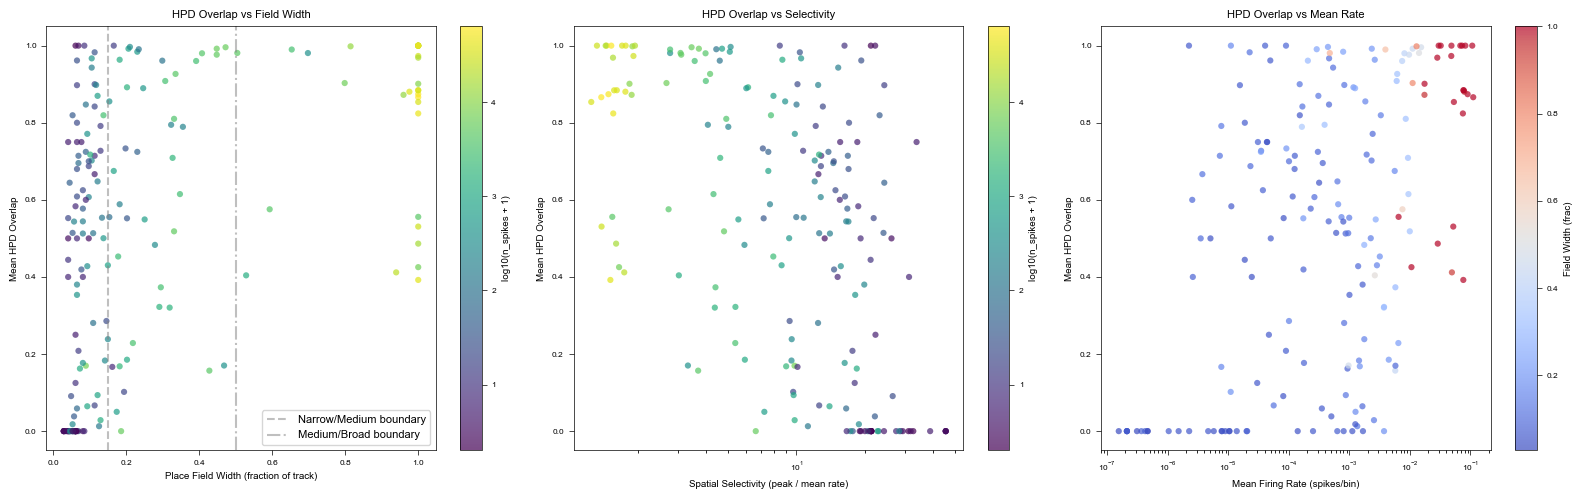

In [11]:
# Key plot: HPD overlap vs place field width, colored by spike count
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Mean HPD overlap vs field width
ax = axes[0]
sc = ax.scatter(
    field_width_frac,
    mean_hpd_per_cell,
    c=np.log10(n_spikes_per_cell + 1),
    cmap="viridis",
    s=20,
    alpha=0.7,
    edgecolors="none",
)
ax.set_xlabel("Place Field Width (fraction of track)")
ax.set_ylabel("Mean HPD Overlap")
ax.set_title("HPD Overlap vs Field Width")
ax.axvline(0.15, color="gray", linestyle="--", alpha=0.5, label="Narrow/Medium boundary")
ax.axvline(0.50, color="gray", linestyle="-.", alpha=0.5, label="Medium/Broad boundary")
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label="log10(n_spikes + 1)")

# Panel B: Mean HPD overlap vs spatial selectivity
ax = axes[1]
sc = ax.scatter(
    selectivity,
    mean_hpd_per_cell,
    c=np.log10(n_spikes_per_cell + 1),
    cmap="viridis",
    s=20,
    alpha=0.7,
    edgecolors="none",
)
ax.set_xlabel("Spatial Selectivity (peak / mean rate)")
ax.set_ylabel("Mean HPD Overlap")
ax.set_title("HPD Overlap vs Selectivity")
ax.set_xscale("log")
plt.colorbar(sc, ax=ax, label="log10(n_spikes + 1)")

# Panel C: Mean HPD overlap vs mean firing rate
ax = axes[2]
valid = mean_rate > 0
sc = ax.scatter(
    mean_rate[valid],
    mean_hpd_per_cell[valid],
    c=field_width_frac[valid],
    cmap="coolwarm",
    s=20,
    alpha=0.7,
    edgecolors="none",
)
ax.set_xlabel("Mean Firing Rate (spikes/bin)")
ax.set_ylabel("Mean HPD Overlap")
ax.set_title("HPD Overlap vs Mean Rate")
ax.set_xscale("log")
plt.colorbar(sc, ax=ax, label="Field Width (frac)")

fig.tight_layout()
plt.show()

## 6. Mechanistic Demonstration

To make the logic explicit, let's pick one narrow-field cell and one broad-field cell
and show exactly what happens to their likelihood vs the predictive posterior.

**The key computation**: When a cell fires (k=1), its single-spike likelihood at each
position bin is `Poisson(k=1 | lambda=place_field_rate)`. This is then normalized to
sum to 1 over bins.

- For a **narrow-field cell**: the likelihood is a peaked distribution centered on the place field.
- For a **broad-field cell**: the likelihood is spread across the track.

The HPD overlap then asks: what fraction of this likelihood falls in the predictive
posterior's 95% HPD region?

In [12]:
# Rates in (n_bins, n_cells) format for likelihood computation
# This matches the format used in compute_per_cell_diagnostics_from_rates
rates_interior = pf.T  # (n_bins, n_cells)

# Pick representative cells
# Narrow: highest selectivity among cells with enough spikes
enough_spikes = total_spikes_per_cell > 100
narrow_candidates = np.where(is_narrow & enough_spikes)[0]
broad_candidates = np.where(is_broad & enough_spikes)[0]

if len(narrow_candidates) > 0:
    narrow_cell = narrow_candidates[np.argmax(selectivity[narrow_candidates])]
else:
    narrow_cell = np.nanargmax(selectivity)

if len(broad_candidates) > 0:
    broad_cell = broad_candidates[np.argmin(selectivity[broad_candidates])]
else:
    broad_cell = np.nanargmin(selectivity)

print(
    f"Narrow cell {narrow_cell}: width={field_width_frac[narrow_cell]:.3f}, "
    f"selectivity={selectivity[narrow_cell]:.1f}, spikes={total_spikes_per_cell[narrow_cell]}"
)
print(
    f"Broad cell {broad_cell}:  width={field_width_frac[broad_cell]:.3f}, "
    f"selectivity={selectivity[broad_cell]:.1f}, spikes={total_spikes_per_cell[broad_cell]}"
)

# Compute their single-spike likelihoods (k=1)
# This is EXACTLY the computation done in analysis.py:597
#   lik_at_spikes = poisson.pmf(k=1, mu=rates_at_spikes)
#   lik_at_spikes = normalize(lik_at_spikes, axis=1)

lik_narrow = poisson.pmf(k=1, mu=rates_interior[:, narrow_cell])
lik_narrow_norm = lik_narrow / lik_narrow.sum()

lik_broad = poisson.pmf(k=1, mu=rates_interior[:, broad_cell])
lik_broad_norm = lik_broad / lik_broad.sum()

print(
    f"\nNarrow cell likelihood entropy: {-np.sum(lik_narrow_norm * np.log(lik_narrow_norm + 1e-30)):.3f} nats"
)
print(
    f"Broad cell likelihood entropy:  {-np.sum(lik_broad_norm * np.log(lik_broad_norm + 1e-30)):.3f} nats"
)
print(f"Maximum entropy (uniform):      {np.log(n_bins_interior):.3f} nats")

Narrow cell 113: width=0.044, selectivity=28.4, spikes=192
Broad cell 176:  width=1.000, selectivity=1.2, spikes=34333

Narrow cell likelihood entropy: 2.925 nats
Broad cell likelihood entropy:  5.504 nats
Maximum entropy (uniform):      5.513 nats


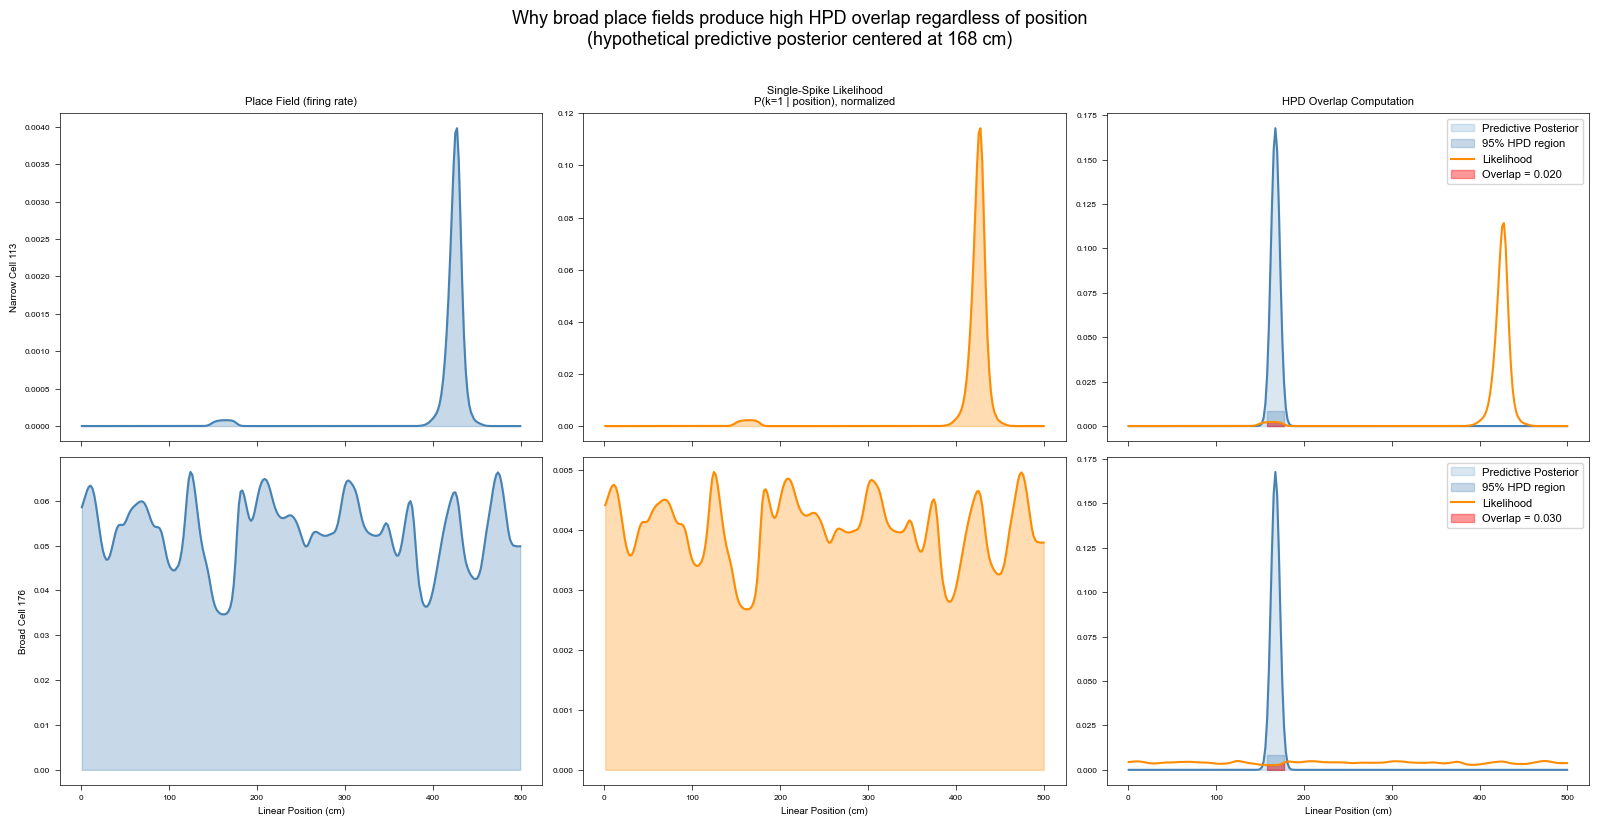

In [13]:
# Visualize: place field, single-spike likelihood, and overlap with a hypothetical
# concentrated predictive posterior

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

# Create a hypothetical concentrated predictive posterior
# (Gaussian-like, centered at some position)
center_pos = pos[len(pos) // 3]  # pick a position away from both cells' peaks
sigma_pred = 5.0  # narrow for movement_var=0.1
pred_posterior = np.exp(-0.5 * ((pos - center_pos) / sigma_pred) ** 2)
pred_posterior = pred_posterior / pred_posterior.sum()

# Compute HPD region (95% coverage)
sorted_pred = np.sort(pred_posterior)[::-1]
cumsum = np.cumsum(sorted_pred)
threshold_val = sorted_pred[np.searchsorted(cumsum, 0.95)]
hpd_mask = pred_posterior >= threshold_val

for row, (cell_idx, cell_name, lik_norm) in enumerate(
    [
        (narrow_cell, "Narrow", lik_narrow_norm),
        (broad_cell, "Broad", lik_broad_norm),
    ]
):
    # Column 0: Place field (raw rate)
    ax = axes[row, 0]
    ax.fill_between(pos, pf[cell_idx], alpha=0.3, color="steelblue")
    ax.plot(pos, pf[cell_idx], color="steelblue", linewidth=1.5)
    ax.set_ylabel(f"{cell_name} Cell {cell_idx}")
    if row == 0:
        ax.set_title("Place Field (firing rate)")

    # Column 1: Normalized single-spike likelihood
    ax = axes[row, 1]
    ax.fill_between(pos, lik_norm, alpha=0.3, color="darkorange")
    ax.plot(pos, lik_norm, color="darkorange", linewidth=1.5)
    if row == 0:
        ax.set_title("Single-Spike Likelihood\nP(k=1 | position), normalized")

    # Column 2: Overlap visualization
    ax = axes[row, 2]
    # Show predictive posterior
    ax.fill_between(pos, pred_posterior, alpha=0.2, color="steelblue", label="Predictive Posterior")
    ax.plot(pos, pred_posterior, color="steelblue", linewidth=1.5)
    # Show HPD region
    ax.fill_between(
        pos,
        0,
        pred_posterior.max() * 0.05,
        where=hpd_mask,
        alpha=0.3,
        color="steelblue",
        label="95% HPD region",
    )
    # Show likelihood
    ax.plot(pos, lik_norm, color="darkorange", linewidth=1.5, label="Likelihood")
    # Highlight overlap
    overlap = np.sum(lik_norm[hpd_mask])
    ax.fill_between(
        pos, lik_norm, where=hpd_mask, alpha=0.4, color="red", label=f"Overlap = {overlap:.3f}"
    )
    ax.legend(fontsize=8, loc="upper right")
    if row == 0:
        ax.set_title("HPD Overlap Computation")

for ax in axes[-1]:
    ax.set_xlabel("Linear Position (cm)")

fig.suptitle(
    "Why broad place fields produce high HPD overlap regardless of position\n"
    f"(hypothetical predictive posterior centered at {center_pos:.0f} cm)",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
plt.show()

## 7. HPD Overlap Distributions by Cell Category

Let's look at the full distribution of HPD overlap values (across all spike events)
for each cell category.

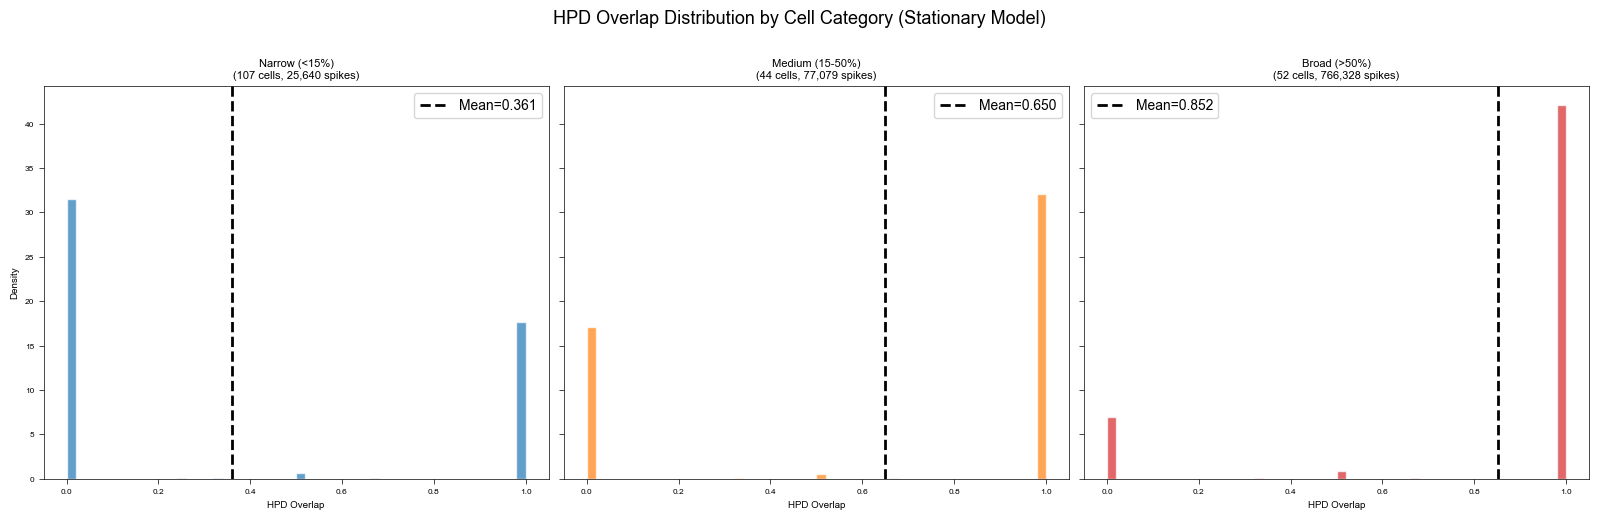

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

categories = [
    ("Narrow (<15%)", is_narrow, "#1f77b4"),
    ("Medium (15-50%)", is_medium, "#ff7f0e"),
    ("Broad (>50%)", is_broad, "#d62728"),
]

bins_hist = np.linspace(0, 1, 51)

for ax_idx, (cat_name, cat_mask, color) in enumerate(categories):
    ax = axes[ax_idx]
    cat_hpd = hpd[:, cat_mask]
    cat_values = cat_hpd[~np.isnan(cat_hpd)]

    ax.hist(cat_values, bins=bins_hist, density=True, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(
        cat_values.mean(),
        color="black",
        linewidth=2,
        linestyle="--",
        label=f"Mean={cat_values.mean():.3f}",
    )
    ax.set_xlabel("HPD Overlap")
    ax.set_title(f"{cat_name}\n({cat_mask.sum()} cells, {len(cat_values):,} spikes)")
    ax.legend(fontsize=10)

axes[0].set_ylabel("Density")
fig.suptitle("HPD Overlap Distribution by Cell Category (Stationary Model)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 8. Same Analysis for KL Divergence

KL divergence is the other diagnostic. Let's check if it shows the same pattern.
KL divergence measures the information lost when using the likelihood to approximate
the predictive posterior. For broad-field cells, the likelihood is spread out, so KL
should be large (the likelihood is a poor approximation of the concentrated posterior).

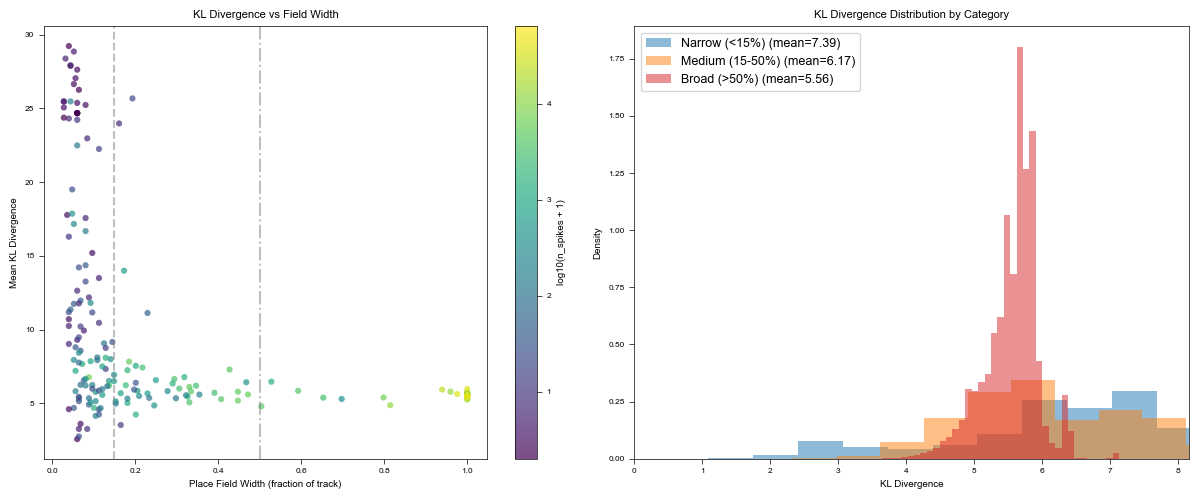

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: KL divergence vs field width
ax = axes[0]
sc = ax.scatter(
    field_width_frac,
    mean_kl_per_cell,
    c=np.log10(n_spikes_per_cell + 1),
    cmap="viridis",
    s=20,
    alpha=0.7,
    edgecolors="none",
)
ax.set_xlabel("Place Field Width (fraction of track)")
ax.set_ylabel("Mean KL Divergence")
ax.set_title("KL Divergence vs Field Width")
ax.axvline(0.15, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0.50, color="gray", linestyle="-.", alpha=0.5)
plt.colorbar(sc, ax=ax, label="log10(n_spikes + 1)")

# Panel B: KL distributions by category
ax = axes[1]
for cat_name, cat_mask, color in categories:
    cat_kl = kl[:, cat_mask]
    cat_values = cat_kl[~np.isnan(cat_kl)]
    ax.hist(
        cat_values,
        bins=50,
        density=True,
        alpha=0.5,
        color=color,
        label=f"{cat_name} (mean={cat_values.mean():.2f})",
    )

ax.set_xlabel("KL Divergence")
ax.set_ylabel("Density")
ax.set_title("KL Divergence Distribution by Category")
ax.legend(fontsize=9)
ax.set_xlim(0, np.nanpercentile(kl, 99))

fig.tight_layout()
plt.show()

## 9. What If We Exclude Broad-Field Cells?

If broad-field cells are inflating HPD overlap, excluding them should lower the mean.
This tests our hypothesis directly.

In [16]:
# Compare overall mean with and without broad-field cells
all_values = hpd[~np.isnan(hpd)]
narrow_medium_values = hpd[:, ~is_broad][~np.isnan(hpd[:, ~is_broad])]
narrow_only_values = hpd[:, is_narrow][~np.isnan(hpd[:, is_narrow])]

print("=== HPD Overlap: Effect of Excluding Broad-Field Cells ===")
print("")
print(
    f"All cells:              mean={all_values.mean():.4f}  ({len(all_values):,} spikes from {n_cells} cells)"
)
print(
    f"Narrow + Medium only:   mean={narrow_medium_values.mean():.4f}  ({len(narrow_medium_values):,} spikes from {(~is_broad).sum()} cells)"
)
print(
    f"Narrow only:            mean={narrow_only_values.mean():.4f}  ({len(narrow_only_values):,} spikes from {is_narrow.sum()} cells)"
)
print("")
print(f"Difference (all - narrow+medium): {all_values.mean() - narrow_medium_values.mean():.4f}")
print(f"Difference (all - narrow only):   {all_values.mean() - narrow_only_values.mean():.4f}")

=== HPD Overlap: Effect of Excluding Broad-Field Cells ===

All cells:              mean=0.8195  (869,047 spikes from 203 cells)
Narrow + Medium only:   mean=0.5777  (102,719 spikes from 151 cells)
Narrow only:            mean=0.3611  (25,640 spikes from 107 cells)

Difference (all - narrow+medium): 0.2419
Difference (all - narrow only):   0.4585


## 10. Likelihood Entropy Analysis

A more principled way to quantify "how informative is this cell?" is to look at the
**entropy of the normalized single-spike likelihood**. This is directly determined by
the place field shape.

- **High entropy** = likelihood is spread out = cell provides little position information = HPD overlap will always be high.
- **Low entropy** = likelihood is concentrated = cell provides strong position information = HPD overlap varies with model quality.

In [17]:
# Compute entropy of normalized single-spike likelihood for each cell
lik_entropy = np.zeros(n_cells)
max_entropy = np.log(n_bins_interior)

for i in range(n_cells):
    lik_i = poisson.pmf(k=1, mu=rates_interior[:, i])
    lik_i_norm = lik_i / (lik_i.sum() + 1e-30)
    lik_entropy[i] = -np.sum(lik_i_norm * np.log(lik_i_norm + 1e-30))

# Relative entropy (1.0 = uniform = completely uninformative)
relative_entropy = lik_entropy / max_entropy

print(f"Maximum entropy (uniform): {max_entropy:.3f} nats")
print(
    f"Likelihood entropy: min={lik_entropy.min():.3f}, median={np.median(lik_entropy):.3f}, max={lik_entropy.max():.3f}"
)
print(
    f"Relative entropy: min={relative_entropy.min():.3f}, median={np.median(relative_entropy):.3f}, max={relative_entropy.max():.3f}"
)

# How many cells have near-uniform likelihoods?
near_uniform = relative_entropy > 0.9
print(
    f"\nCells with relative entropy > 0.9 (near-uniform likelihood): {near_uniform.sum()} / {n_cells}"
)
print(f"Their mean HPD overlap: {np.nanmean(mean_hpd_per_cell[near_uniform]):.4f}")
print(f"Remaining cells' mean HPD overlap: {np.nanmean(mean_hpd_per_cell[~near_uniform]):.4f}")

Maximum entropy (uniform): 5.513 nats
Likelihood entropy: min=2.094, median=4.206, max=5.513
Relative entropy: min=0.380, median=0.763, max=1.000

Cells with relative entropy > 0.9 (near-uniform likelihood): 68 / 203
Their mean HPD overlap: 0.8177
Remaining cells' mean HPD overlap: 0.4265


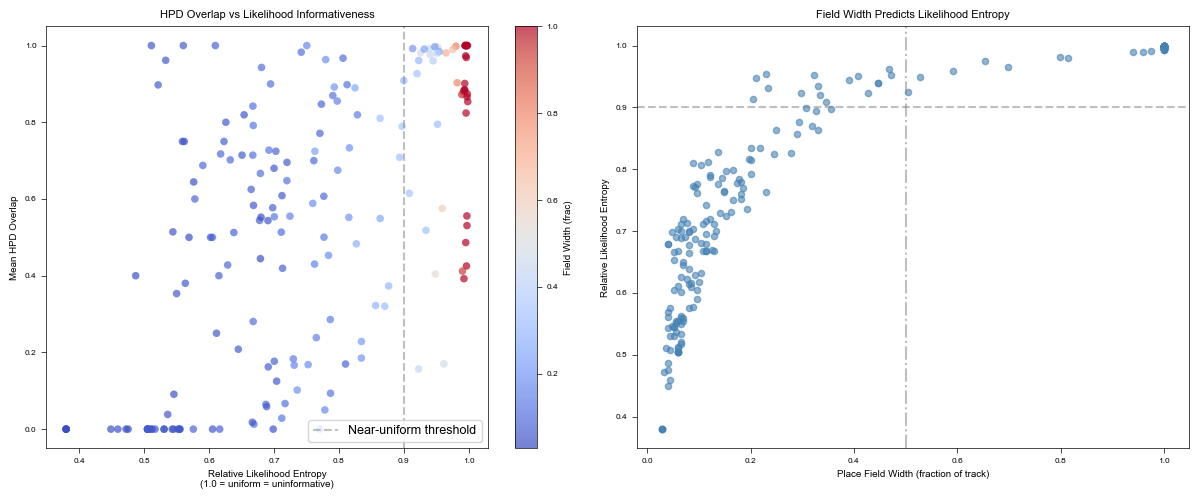

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: HPD overlap vs likelihood entropy
ax = axes[0]
sc = ax.scatter(
    relative_entropy,
    mean_hpd_per_cell,
    c=field_width_frac,
    cmap="coolwarm",
    s=30,
    alpha=0.7,
    edgecolors="none",
)
ax.set_xlabel("Relative Likelihood Entropy\n(1.0 = uniform = uninformative)")
ax.set_ylabel("Mean HPD Overlap")
ax.set_title("HPD Overlap vs Likelihood Informativeness")
ax.axvline(0.9, color="gray", linestyle="--", alpha=0.5, label="Near-uniform threshold")
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="Field Width (frac)")

# Panel B: Likelihood entropy vs field width (should be correlated)
ax = axes[1]
ax.scatter(field_width_frac, relative_entropy, s=20, alpha=0.6, color="steelblue")
ax.set_xlabel("Place Field Width (fraction of track)")
ax.set_ylabel("Relative Likelihood Entropy")
ax.set_title("Field Width Predicts Likelihood Entropy")
ax.axhline(0.9, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0.50, color="gray", linestyle="-.", alpha=0.5)

fig.tight_layout()
plt.show()

## 11. Summary

### The Chain of Logic

1. **The stationary model** uses `movement_var=0.1`, making the predictive posterior very
   concentrated (barely spreads from the filtered posterior).

2. **HPD overlap** measures what fraction of a cell's single-spike likelihood falls inside
   the predictive posterior's 95% HPD region.

3. **When a cell fires (k=1)**, its likelihood at each position bin is
   `Poisson(k=1 | lambda=place_field_rate)`, normalized over bins.

4. **For cells with broad/flat place fields**, the Poisson likelihood `P(k=1|lambda)` is
   similar across many position bins (because lambda varies little). The normalized
   likelihood is therefore spread out — near uniform.

5. **A near-uniform likelihood always overlaps substantially with any concentrated HPD region**,
   because it assigns non-negligible probability to every position bin, including those in
   the HPD region.

6. **Result**: Broad-field cells (and putative interneurons with flat spatial tuning) have
   high HPD overlap **regardless of whether the model is correctly tracking position**.
   They inflate the population mean HPD overlap.

### Quantitative Summary

In [19]:
print("=" * 70)
print("SUMMARY: What Drives High HPD Overlap in the Stationary Model?")
print("=" * 70)
print()
print(f"Total cells: {n_cells}")
print(f"Overall mean HPD overlap: {np.nanmean(hpd):.4f}")
print()
print("By place field category:")
print(f"{'Category':20s} {'Cells':>6s} {'Spikes':>10s} {'Mean HPD':>10s} {'Contribution':>12s}")
print("-" * 62)

total_spikes_all = np.sum(~np.isnan(hpd))
for cat_name, cat_mask in [
    ("Narrow (<15%)", is_narrow),
    ("Medium (15-50%)", is_medium),
    ("Broad (>50%)", is_broad),
]:
    cat_hpd = hpd[:, cat_mask]
    cat_vals = cat_hpd[~np.isnan(cat_hpd)]
    n = cat_mask.sum()
    ns = len(cat_vals)
    m = cat_vals.mean() if len(cat_vals) > 0 else float("nan")
    contrib = m * ns / total_spikes_all
    print(f"{cat_name:20s} {n:6d} {ns:10,d} {m:10.4f} {contrib:12.4f}")

print(f"{'Total':20s} {n_cells:6d} {total_spikes_all:10,d} {np.nanmean(hpd):10.4f}")
print()
print("Key finding: Broad-field cells have consistently high HPD overlap")
print("because their likelihoods are spread across the track, ensuring")
print("overlap with any concentrated predictive posterior.")

SUMMARY: What Drives High HPD Overlap in the Stationary Model?

Total cells: 203
Overall mean HPD overlap: 0.8195

By place field category:
Category              Cells     Spikes   Mean HPD Contribution
--------------------------------------------------------------
Narrow (<15%)           107     25,640     0.3611       0.0107
Medium (15-50%)          44     77,079     0.6497       0.0576
Broad (>50%)             52    766,328     0.8520       0.7513
Total                   203    869,047     0.8195

Key finding: Broad-field cells have consistently high HPD overlap
because their likelihoods are spread across the track, ensuring
overlap with any concentrated predictive posterior.
